In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import seaborn as sns

ACCENT, GREY, LIGHT = "#1F6F8B", "#9AA8B3", "#C9D6DC"
PAIR = [ACCENT, GREY]
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (8, 4.2),
              "axes.spines.top": False, "axes.spines.right": False})
 
def hbar(data, y, x, ax, fmt="{:,.0f}", color=ACCENT):
    """Horizontal seaborn bar chart in the frame's order, with value labels."""
    sns.barplot(data=data, y=y, x=x, ax=ax, color=color, orient="h", order=list(data[y]))
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in data[x]], padding=3, fontsize=8)
    ax.set_xlim(0, data[x].max() * 1.18)
    ax.set_ylabel("")
 
def paired_share(data, cat, cols, names, ax):
    """Two percentage columns side by side per category (e.g. % repos vs % files)."""
    long = data.melt(id_vars=cat, value_vars=cols, var_name="measure", value_name="pct")
    long["measure"] = long.measure.map(dict(zip(cols, names)))
    sns.barplot(data=long, x=cat, y="pct", hue="measure", palette=PAIR, ax=ax, order=list(data[cat]))
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f", fontsize=8)
    ax.set_ylabel("%"); ax.legend(title="")

repos_path = '../data/gitskills_data/data/repos/*.parquet'
artifacts_path = '../data/gitskills_data/data/artifacts/*.parquet'
artifact_siblings_path = '../data/gitskills_data/data/artifact_siblings/*.parquet'
mining_runs_path = '../data/gitskills_data/data/mining_runs/*.parquet'
skill_features_path = '../data/generated_data/skill_features.parquet'
file_agents_path = '../data/generated_data/file_agents.parquet'
sibling_files_path = '../data/generated_data/sibling_files.parquet'

con = duckdb.connect(database=':memory:')

## Bundled files (siblings)

A skill is a `SKILL.md` plus any other files that live in the same folder (scripts, references, configs). Coverage below is counted on deduplicated skills (`dedup_primary = 1`). File-level breakdowns use `sibling_files.parquet`, built from `artifact_siblings` in `db/siblings_data.sql`.

#### Coverage: how many skills bundle anything?

In [15]:
coverage = con.execute(f"""
SELECT COUNT(*)                                   AS distinct_skills,
       COUNT_IF(composition_fetched = 1)          AS folder_listed,
       COUNT_IF(sibling_count > 0)                AS with_bundled_files,
       ROUND(100.0 * COUNT_IF(sibling_count > 0) / COUNT(*), 1) AS pct_with_bundled,
       COUNT_IF(has_scripts = 1)                  AS with_scripts,
       COUNT_IF(has_references = 1)               AS with_references,
       COUNT_IF(composition_truncated = 1)        AS listing_truncated
FROM read_parquet('{artifacts_path}')
WHERE dedup_primary = 1
""").df()
coverage.T.rename(columns={0: "value"})

,value
distinct_skills,1877981.0
folder_listed,1876437.0
with_bundled_files,682273.0
pct_with_bundled,36.3
with_scripts,214507.0
with_references,485979.0
listing_truncated,252250.0


Folder contents were listed for nearly every skill (1,876,437 of 1,877,981,
99.9%). Just over a third of skills (36.3%, 682,273) bundle at least one file
besides `SKILL.md`: 25.9% (485,979) include reference material and 11.4%
(214,507) include scripts. So most skills are a single instruction file, and
roughly one in nine ships code an agent may execute. Listings were truncated
for 13.4% of skills (252,250), so bundle sizes for very large folders below
are lower bounds.

#### Bundled files per skill
Skills with at least one bundled file. `median_total_bytes` is the median of the summed file sizes in that skill's folder.

In [16]:
bundled_per_skill = con.execute(f"""
WITH k AS (
  SELECT repo_full_name, artifact_path, COUNT(*) AS files, SUM(entry_size) AS bytes
  FROM read_parquet('{sibling_files_path}') GROUP BY 1, 2
)
SELECT CASE WHEN files = 1 THEN '1' WHEN files <= 3 THEN '2-3' WHEN files <= 10 THEN '4-10'
            WHEN files <= 50 THEN '11-50' ELSE '>50' END AS bundled_files,
       MIN(files) AS sort_key, COUNT(*) AS skills,
       median(bytes) AS median_total_bytes
FROM k GROUP BY 1 ORDER BY sort_key
""").df()
bundled_per_skill

,bundled_files,sort_key,skills,median_total_bytes
0,1,1,255558,1842.0
1,2-3,2,168340,9488.0
2,4-10,4,169354,27351.5
3,11-50,11,71589,105305.0
4,>50,51,18093,1102462.0


Among skills that bundle anything, most bundles are small: 37.4% have a single
extra file (median 1.8 KB in total) and a further 49.4% have 2–10 files. A tail
of 18,093 skills (2.6%) bundles more than 50 files, with a median of 1.1 MB per
skill — entire mini-projects rather than supporting notes. The two ends reflect
different kinds of skill: an instruction file with a helper script or
reference, versus a packaged tool that happens to include a `SKILL.md`.

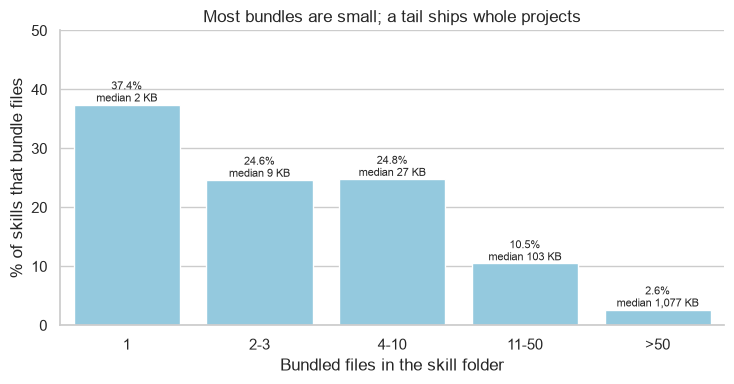

In [17]:
b = bundled_per_skill.assign(pct=lambda d: 100 * d.skills / d.skills.sum())
size = lambda s: f"{s/1024:,.0f} KB" if s >= 1024 else f"{s:,.0f} B"
fig, ax = plt.subplots(figsize=(7.5, 4))
sns.barplot(data=b, x="bundled_files", y="pct", color="skyblue", order=list(b.bundled_files), ax=ax)
ax.bar_label(ax.containers[0], labels=[f"{p:.1f}%\nmedian {size(s)}" for p, s in zip(b.pct, b.median_total_bytes)], fontsize=8)
ax.set_xlabel("Bundled files in the skill folder"); ax.set_ylabel("% of skills that bundle files")
ax.set_ylim(0, 50); ax.set_title("Most bundles are small; a tail ships whole projects")
plt.tight_layout(); plt.show()

#### What kinds of files are bundled?

In [18]:
file_kinds = con.execute(f"""
SELECT file_category,
       COUNT(*)                                          AS files,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_files,
       COUNT(DISTINCT repo_full_name || '/' || artifact_path) AS skills_with_it
FROM read_parquet('{sibling_files_path}')
GROUP BY 1 ORDER BY files DESC
""").df()
file_kinds

,file_category,files,pct_files,skills_with_it
0,documentation,2923069,49.9,486586
1,script / code,1414648,24.1,228068
2,data / config,619188,10.6,241411
3,other,343508,5.9,78410
4,media / asset,252140,4.3,18804
5,web / template,226736,3.9,26765
6,no extension,79656,1.4,42118


Half of all bundled files (49.9%) are documentation, found in 486,586 skills,
typically reference pages the agent loads on demand. Scripts and code are the
second-largest group (24.1% of files, in 228,068 skills, 12.1% of all distinct
skills), followed by data and configuration (10.6%). Media, web assets and
templates together make up under 9%. Bundles therefore mostly extend a skill's
instructions; executable code is common but secondary.

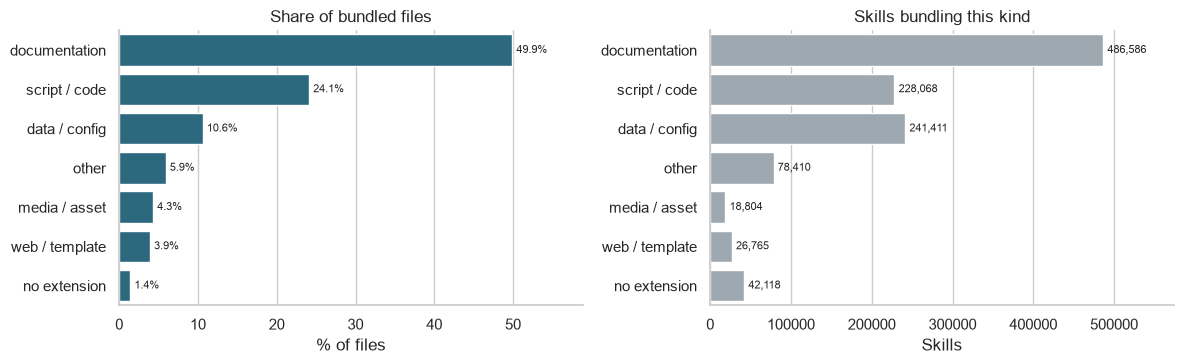

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
hbar(file_kinds, "file_category", "pct_files", axes[0], fmt="{:.1f}%")
axes[0].set_title("Share of bundled files"); axes[0].set_xlabel("% of files")
hbar(file_kinds, "file_category", "skills_with_it", axes[1], color=GREY)
axes[1].set_title("Skills bundling this kind"); axes[1].set_xlabel("Skills")
plt.tight_layout(); plt.show()

#### Script languages

In [20]:
script_languages = con.execute(f"""
SELECT ext, COUNT(*) AS files,
       COUNT(DISTINCT repo_full_name || '/' || artifact_path) AS skills
FROM read_parquet('{sibling_files_path}')
WHERE file_category = 'script / code'
GROUP BY 1 ORDER BY files DESC LIMIT 12
""").df()
script_languages

,ext,files,skills
0,py,619273,142884
1,ts,234527,18096
2,sh,141203,58494
3,js,138471,22117
4,go,97097,1813
5,mjs,60114,11508
6,rs,27181,2036
7,cs,15140,908
8,ps1,14657,6327
9,java,13971,688


Python dominates bundled code: 142,884 skills ship `.py` files, about 63% of
skills with scripts. Shell scripts follow (58,494 skills), then JavaScript
(22,117) and TypeScript (18,096), with PowerShell (6,327) the main
Windows-specific option. File counts and skill counts diverge for some
languages: Go appears in only 1,813 skills but with 97,097 files (about 54 per
skill), and Rust, C# and Java show the same pattern, indicating full source
projects bundled into a skill folder rather than small helper scripts.

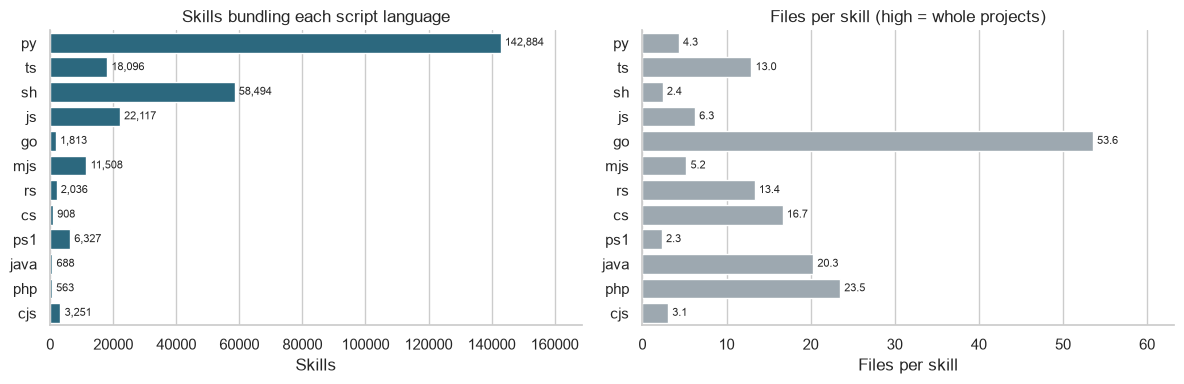

In [21]:
sl = script_languages.assign(files_per_skill=lambda d: d.files / d.skills)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hbar(sl, "ext", "skills", axes[0]); axes[0].set_title("Skills bundling each script language"); axes[0].set_xlabel("Skills")
hbar(sl, "ext", "files_per_skill", axes[1], fmt="{:.1f}", color=GREY)
axes[1].set_title("Files per skill (high = whole projects)"); axes[1].set_xlabel("Files per skill")
plt.tight_layout(); plt.show()

#### Folder conventions inside a skill

In [22]:
folder_conventions = con.execute(f"""
SELECT subfolder,
       COUNT(DISTINCT repo_full_name || '/' || artifact_path) AS skills,
       COUNT(*) AS files
FROM read_parquet('{sibling_files_path}')
GROUP BY 1 ORDER BY skills DESC LIMIT 15
""").df()
folder_conventions

,subfolder,skills,files
0,(skill root),349762,820578
1,references,282346,1447176
2,scripts,167215,631050
3,agents,69759,87886
4,assets,44132,215178
5,examples,29738,123660
6,templates,29340,150943
7,evals,21930,48435
8,tests,13204,90798
9,reference,9367,70919


Skills follow a shared internal layout. After files at the skill root, the most
common subfolders are `references/` (282,346 skills), `scripts/` (167,215),
`agents/` (69,759), `assets/` (44,132), `examples/` (29,738) and `templates/`
(29,340), matching the structure recommended in Anthropic's skill guidance.
`evals/` (21,930 skills) points to skills built or tested with the
`skill-creator` evaluation workflow. Naming is not fully standardized:
`reference/` and `resources/` coexist with `references/`, and folders such as
`src/`, `tests/` and `.github/` again indicate whole projects inside skill
folders.

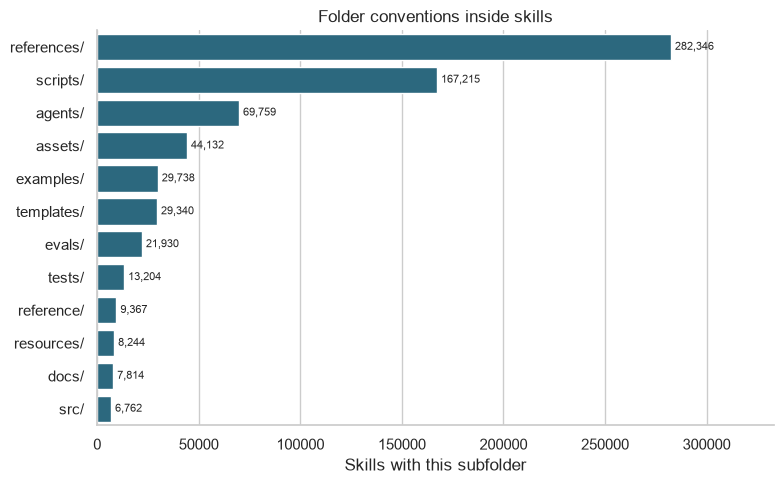

In [23]:
fc = (folder_conventions[folder_conventions.subfolder != "(skill root)"].head(12)
      .assign(subfolder=lambda d: d.subfolder + "/"))
fig, ax = plt.subplots(figsize=(8, 5))
hbar(fc, "subfolder", "skills", ax)
ax.set_xlabel("Skills with this subfolder"); ax.set_title("Folder conventions inside skills")
plt.tight_layout(); plt.show()

#### Are bundled files themselves reused across skills?
`pct_duplicate` is the share of bundled-file rows whose bytes also appear in another skill.

In [17]:
bundled_reuse = con.execute(f"""
SELECT COUNT(*)                          AS bundled_files,
       COUNT(DISTINCT entry_sha)         AS distinct_contents,
       ROUND(100.0 * (1 - COUNT(DISTINCT entry_sha) * 1.0 / COUNT(*)), 1) AS pct_duplicate
FROM read_parquet('{sibling_files_path}')
""").df()
bundled_reuse.T.rename(columns={0: "value"})

,value
bundled_files,5858945.0
distinct_contents,4248933.0
pct_duplicate,27.5


Bundled files are copied far more than the sample suggested: 27.5% of the
5,858,945 bundled-file rows duplicate bytes found in another skill (4,248,933
distinct contents). Copying therefore extends beyond `SKILL.md` to the files
that travel with it, which matters for security analysis: a script copied into
thousands of skills spreads whatever it does to all of them.

Most reused bundled files (the same bytes in many different skills).

`e69de29bb2d1d6434b8b29ae775ad8c2e48c5391` is git's hash for an empty file (`.gitkeep`, placeholder scripts).

In [18]:
most_reused = con.execute(f"""
SELECT entry_sha, any_value(entry_name) AS example_name, file_category,
       COUNT(DISTINCT repo_full_name || '/' || artifact_path) AS skills
FROM read_parquet('{sibling_files_path}')
GROUP BY entry_sha, file_category
ORDER BY skills DESC LIMIT 15
""").df()
most_reused

,entry_sha,example_name,file_category,skills
0,d8851182d0218e298f8b852802581c545c60b897,LICENSE,no extension,9917
1,e69de29bb2d1d6434b8b29ae775ad8c2e48c5391,analyses/.gitkeep,other,6831
2,e69de29bb2d1d6434b8b29ae775ad8c2e48c5391,media-researcher-core/tests/__init__.py,script / code,6643
3,7a4a3ea2424c09fbe48d455aed1eaa94d9124835,LICENSE.txt,documentation,2504
4,c55ab42224874608473643de0a85736b7fec0730,LICENSE.txt,documentation,1626
5,462524f94acfd7ca1e8892e4796917e8c2de7251,references/senior-master-standard.md,documentation,1263
6,1dbf05140d07fa014f18a5630acc0613d8058e52,scripts/office/schemas/ISO-IEC29500-4_2016/dml...,other,1137
7,687eea8297caa298581aa06c40ca40ef7b8a58bc,scripts/office/schemas/ISO-IEC29500-4_2016/dml...,other,1136
8,afa4f463e3140a3f626c73f7966d689270d89b2c,scripts/office/schemas/ISO-IEC29500-4_2016/dml...,other,1136
9,5c42706a0d53c5e8b96818d9c29a292d1504f720,scripts/office/schemas/ISO-IEC29500-4_2016/sha...,other,1135


The most reused bundled files are boilerplate rather than skill logic: a
`LICENSE` file in 9,917 skills and further `LICENSE.txt` variants in over
4,000. Git's empty-file hash appears in about 13,500 skills under names such as
`assets/.gitkeep` and `public/stats.js`, i.e. placeholders and empty stubs.
The Office Open XML schema files bundled with Anthropic's `pptx` document skill
each appear in about 1,135 skills, showing that official skill packs are
copied with their full folders. One reference document,
`references/senior-master-standard.md`, recurs in 1,263 skills, a sign of a
widely replicated template collection.

#### Files the collector skipped, and why

In [19]:
skipped = con.execute(f"""
SELECT coalesce(CAST(skipped_reason AS VARCHAR), '(not skipped)') AS skipped_reason, COUNT(*) AS files
FROM read_parquet('{sibling_files_path}')
GROUP BY 1 ORDER BY files DESC
""").df()
skipped

,skipped_reason,files
0,(not skipped),5858945


No bundled files were skipped by the collector, so file-level results are not
affected by selective fetching; the only known gap is the truncated listings
noted above.